In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Single Model

## Undersampling

avalia qual metodo de undersamplig teve o melhor resultado

### Accuracy

In [8]:
single_model = "KNeighborsClassifier"

In [9]:

acc = pd.read_json("../models/single_model/tables/accuracy_score.jsonl",
             lines=True,
             orient="records")
acc['timestamp'] = pd.to_datetime(acc['timestamp']).dt.floor('min')
acc.set_index("timestamp", inplace=True)
acc.sort_values(by=['score'], inplace=True)
acc.fillna({'undersampling':'NA'}, inplace=True)

In [ ]:
acc

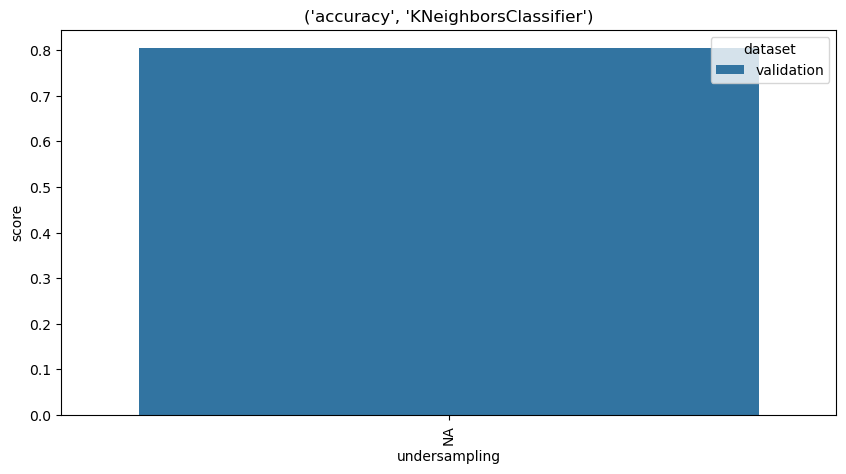

In [10]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=acc.loc[(acc['model_name']==single_model) & (acc['dataset']=='validation')],
    x='undersampling',
    y='score',
    hue='dataset'    
)
plt.title(f'{"accuracy", single_model}')
plt.xticks(rotation=90)
plt.show()

### Roc auc

In [ ]:
rocauc = pd.read_json("../models/single_model/tables/roc_auc_score.jsonl",
             lines=True,
             orient="records")
rocauc['timestamp'] = pd.to_datetime(rocauc['timestamp']).dt.floor('min')
rocauc.set_index("timestamp", inplace=True)
rocauc.sort_values(by=['score'], inplace=True)
rocauc.fillna({'undersampling':'NA'}, inplace=True)

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=rocauc.loc[rocauc['model_name']==single_model],
    x='undersampling',
    y='score',
    hue='dataset'    
)
plt.title(f'"Roc_Auc", {single_model}')
plt.xticks(rotation=90)
plt.show()

### F1

In [ ]:
f1 = pd.read_json("../models/single_model/tables/f1_score.jsonl",
             lines=True,
             orient="records")
f1['timestamp'] = pd.to_datetime(f1['timestamp']).dt.floor('min')
f1.set_index("timestamp", inplace=True)
f1.sort_values(by=['score'], inplace=True)
f1.fillna({'undersampling':'NA'}, inplace=True)

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=f1.loc[f1['model_name']==single_model],
    x='undersampling',
    y='score',
    hue='dataset'    
)
plt.title(f'"f1", {single_model}')
plt.xticks(rotation=90)
plt.show()

## Model

In [ ]:
data = '2026-04'
undersamplig='NA'
dataset = 'validation'

In [ ]:
tmp = (acc
 .loc[(data)]
 .loc[
     (acc['model_name']==single_model) & 
     (acc['undersampling']==undersamplig) & 
     (acc['dataset']==dataset)]
 .sort_index()
 .reset_index()
 )

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=tmp,
    x='timestamp',
    y='score',
    # hue='dataset',
    # palette={'train': 'royalblue', 'validation': 'tomato'}
)
plt.title(
    f'{tmp['metric_name'].unique()[0]}, {tmp['model_name'].unique()[0]},{tmp['dataset'].unique()[0]}')
plt.xticks(rotation=90)
plt.show()

In [ ]:
plt.figure(figsize=(10,5))
sns.pointplot(
    data=tmp,
    x='timestamp',
    y='score',
    # hue='dataset',
    # palette={'train': 'royalblue', 'validation': 'tomato'}
)
plt.title(
    f'{acc['metric_name'].unique()[0]}, {acc['model_name'].unique()[0]},{acc['dataset'].unique()[0]}')
plt.xticks(rotation=90)
plt.show()

# ANN

In [5]:
acc_ann = pd.read_json("../models/ann_model/tables/accuracy_score.jsonl",
             lines=True,
             orient="records")
acc_ann['timestamp'] = pd.to_datetime(acc_ann['timestamp']).dt.floor('min')
acc_ann.set_index("timestamp", inplace=True)
# acc_ann.sort_values(by=['score'], inplace=True)

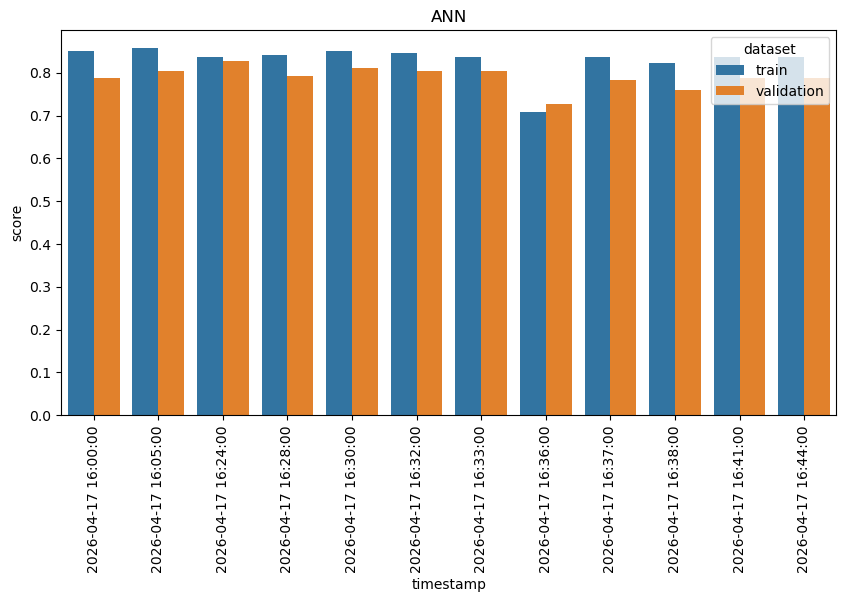

In [6]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=acc_ann,
    x='timestamp',
    y='score',
    hue='dataset'   
)
plt.title('ANN')
plt.xticks(rotation=90)
plt.show()

In [ ]:
clfrpt_ann = pd.read_json("../models/ann_model/tables/classification_report.jsonl",
             lines=True,
             orient="records")
clfrpt_ann['timestamp'] = pd.to_datetime(clfrpt_ann['timestamp']).dt.floor('min')
tmp=pd.json_normalize(clfrpt_ann['report'])
clfrpt_ann = pd.concat([clfrpt_ann, tmp], axis=1)
clfrpt_ann.drop(columns=['report'], inplace=True)

In [ ]:
plt.figure(figsize=(10,5))
sns.pointplot(
    data=clfrpt_ann,
    x='timestamp',
    y='1.f1-score',
    legend=True,
    label=1,

)
sns.pointplot(
    data=clfrpt_ann,
    x='timestamp',
    y='0.f1-score',
    legend=True,
    label=0,

)

plt.xticks(rotation=90)
plt.show()

# Voting Model

In [12]:
acc_v = pd.read_json("../models/voting_model/tables/accuracy_score.jsonl",
             lines=True,
             orient="records")
# acc_v['timestamp'] = pd.to_datetime(acc_v['timestamp']).dt.floor('min')
# acc_v.set_index("timestamp", inplace=True)

In [13]:
acc_v

,model_name,dataset,metric_name,score,undersampling,timestamp
0,voting_model,train,accuracy_score,0.852528,None,2026-03-12 17:27:13.369378
1,voting_model,validation,accuracy_score,0.804469,None,2026-03-12 17:27:13.385923
2,voting_model,train,accuracy_score,0.846910,None,2026-04-16 14:20:29.809609
3,voting_model,validation,accuracy_score,0.787709,None,2026-04-16 14:20:29.811608
4,voting_model,train,accuracy_score,0.846910,None,2026-04-20 09:00:41.749727
5,voting_model,validation,accuracy_score,0.787709,None,2026-04-20 09:00:41.752727
6,voting_model,train,accuracy_score,0.846910,None,2026-04-20 09:06:32.649520
7,voting_model,validation,accuracy_score,0.787709,None,2026-04-20 09:06:32.651522
8,voting_model,train,accuracy_score,0.846910,None,2026-04-20 09:11:22.717486
9,voting_model,validation,accuracy_score,0.787709,None,2026-04-20 09:11:22.718485


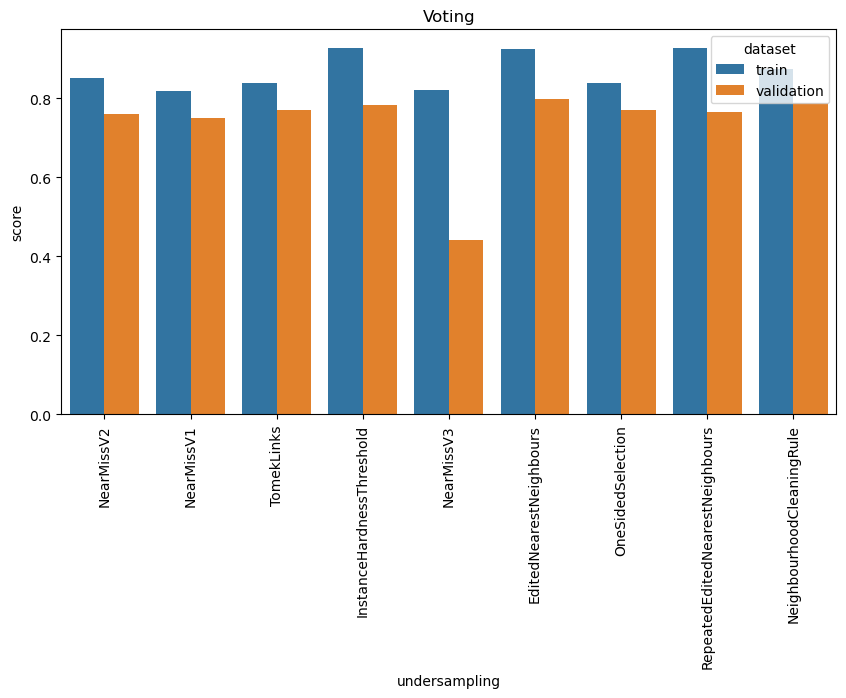

In [14]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=acc_v,
    x='undersampling',
    y='score',
    hue='dataset'   
)
plt.title('Voting')
plt.xticks(rotation=90)
plt.show()